# What-If Fire Pollution Impact Simulator

This notebook creates a model to simulate the pollution impact of a wildfire at any given location.
You can:
- Place a fire anywhere on the map (specify lat/lon)
- Set the fire intensity (FRP - Fire Radiative Power)
- Predict pollution levels for different indicators (CH4, CO, NO2, HCHO, AAI, SO2)
- Visualize the pollution spread based on historical patterns

**Use Case**: This model will power the webapp feature where users can interactively place fires and see pollution impacts.

## 1. Import Libraries

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium import plugins
import branca.colormap as cm

# For modeling
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib

# For spatial calculations
from scipy.spatial.distance import cdist
from scipy.ndimage import gaussian_filter

import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load Historical Fire and Pollution Data

We'll use historical wildfire data and pollution data to build relationships between:
- Fire location (lat/lon)
- Fire intensity (FRP)
- Pollution levels at various distances

In [14]:
# Load NASA MODIS wildfire data
csv_path = "../data/NASA-MODIS-DATA/"
df_fires = pd.read_csv(csv_path + "df_2019_2024.csv")
df_fires['acq_date'] = pd.to_datetime(df_fires['acq_date'])
df_fires.set_index('acq_date', inplace=True)

# Filter to Scandinavia region (adjust if needed)
df_fires = df_fires[
    (df_fires['latitude'] >= 52) & (df_fires['latitude'] <= 72) &
    (df_fires['longitude'] >= -10) & (df_fires['longitude'] <= 40)
].copy()

print(f"Loaded {len(df_fires):,} fire records")
print(f"Date range: {df_fires.index.min()} to {df_fires.index.max()}")
print(f"\nFRP statistics:")
print(df_fires['frp'].describe())

df_fires.head()

Loaded 71,180 fire records
Date range: 2019-01-05 00:00:00 to 2024-12-11 00:00:00

FRP statistics:
count    71180.000000
mean        20.943608
std         36.910457
min          0.000000
25%          6.100000
50%         10.200000
75%         19.400000
max        530.300000
Name: frp, dtype: float64


,latitude,longitude,brightness,scan,track,acq_time,satellite,instrument,confidence,version,bright_t31,frp,daynight,type
acq_date,,,,,,,,,,,,,,
2019-01-05,58.3396,11.4248,311.1,1.0,1.0,1031,Terra,MODIS,54,6.03,274.3,16.0,D,2
2019-01-05,58.3396,11.4248,311.1,1.0,1.0,1031,Terra,MODIS,54,6.03,274.3,16.0,D,2
2019-01-05,58.3396,11.4248,311.1,1.0,1.0,1031,Terra,MODIS,54,6.03,274.3,16.0,D,2
2019-01-05,58.3396,11.4248,311.1,1.0,1.0,1031,Terra,MODIS,54,6.03,274.3,16.0,D,2
2019-01-05,58.3396,11.4248,311.1,1.0,1.0,1031,Terra,MODIS,54,6.03,274.3,16.0,D,2


In [15]:
# TODO: Load pollution data from your Sentinel-5P data
# This would be data from fetchdata-sweden.ipynb
# For now, we'll create a placeholder - replace with actual data

# Example structure - replace with your actual pollution data
# df_pollution = pd.read_csv('../data/pollution_data.csv')
# df_pollution should have columns: date, latitude, longitude, CH4, CO, NO2, HCHO, AAI, SO2

print("⚠️ TODO: Load your Sentinel-5P pollution data here")
print("Expected columns: date, latitude, longitude, CH4, CO, NO2, HCHO, AAI, SO2")

⚠️ TODO: Load your Sentinel-5P pollution data here
Expected columns: date, latitude, longitude, CH4, CO, NO2, HCHO, AAI, SO2


## 3. Build FRP-to-Pollution Relationship Model

We'll create a model that predicts pollution levels based on:
- Fire intensity (FRP)
- Distance from fire
- Season/month (affects dispersion)
- Terrain/region type

In [16]:
# Create synthetic pollution impact model based on FRP
# In production, this should be trained on actual fire-pollution correlations

def create_pollution_impact_model():
    """
    Creates a simple model mapping FRP to pollution levels.
    
    In production, train this on actual historical data correlating:
    - Fire FRP with nearby pollution measurements
    - Account for wind patterns, distance decay, etc.
    """
    
    # Base pollution factors per FRP unit
    # These are placeholder values - calibrate with real data
    pollution_factors = {
        'CO': 0.15,      # CO increases strongly with fire
        'NO2': 0.08,     # Moderate increase
        'CH4': 0.05,     # Slight increase
        'HCHO': 0.06,    # Formaldehyde from combustion
        'SO2': 0.04,     # Sulfur dioxide
        'AAI': 0.10      # Aerosol index (smoke/particles)
    }
    
    return pollution_factors

pollution_model = create_pollution_impact_model()
print("Pollution impact factors:")
for pollutant, factor in pollution_model.items():
    print(f"  {pollutant}: {factor:.3f} per FRP unit")

Pollution impact factors:
  CO: 0.150 per FRP unit
  NO2: 0.080 per FRP unit
  CH4: 0.050 per FRP unit
  HCHO: 0.060 per FRP unit
  SO2: 0.040 per FRP unit
  AAI: 0.100 per FRP unit


## 4. Pollution Dispersion Model

Model how pollution spreads from the fire source using Gaussian dispersion

In [17]:
def calculate_distance_km(lat1, lon1, lat2, lon2):
    """
    Calculate distance in km between two lat/lon points using Haversine formula
    """
    R = 6371  # Earth radius in km
    
    lat1_rad, lon1_rad = np.radians(lat1), np.radians(lon1)
    lat2_rad, lon2_rad = np.radians(lat2), np.radians(lon2)
    
    dlat = lat2_rad - lat1_rad
    dlon = lon2_rad - lon1_rad
    
    a = np.sin(dlat/2)**2 + np.cos(lat1_rad) * np.cos(lat2_rad) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    
    return R * c

def pollution_concentration_at_distance(frp, distance_km, pollutant_factor, 
                                        dispersion_coef=0.5):
    """
    Calculate pollution concentration at a given distance from fire.
    
    Uses simplified Gaussian plume model:
    C(d) = (FRP × factor) × exp(-d² / (2σ²))
    
    Args:
        frp: Fire Radiative Power
        distance_km: Distance from fire source
        pollutant_factor: Base pollution factor for this pollutant
        dispersion_coef: Controls how fast pollution disperses (higher = faster)
    
    Returns:
        Relative pollution concentration
    """
    # Gaussian dispersion
    sigma = 50 * dispersion_coef  # Standard deviation in km
    base_concentration = frp * pollutant_factor
    
    # Distance decay
    decay_factor = np.exp(-distance_km**2 / (2 * sigma**2))
    
    concentration = base_concentration * decay_factor
    
    return concentration

# Test the model
test_frp = 100  # Example FRP
test_distances = [0, 10, 25, 50, 100, 200]

print(f"Pollution dispersion for FRP={test_frp}:\n")
for dist in test_distances:
    co_conc = pollution_concentration_at_distance(test_frp, dist, pollution_model['CO'])
    print(f"  {dist:3d} km: CO concentration = {co_conc:.4f}")

Pollution dispersion for FRP=100:

    0 km: CO concentration = 15.0000
   10 km: CO concentration = 13.8467
   25 km: CO concentration = 9.0980
   50 km: CO concentration = 2.0300
  100 km: CO concentration = 0.0050
  200 km: CO concentration = 0.0000


## 5. Simulate Fire Impact Function

Main function to simulate a fire at any location

In [18]:
def simulate_fire_pollution_impact(fire_lat, fire_lon, frp, 
                                   grid_resolution=0.1, radius_km=200):
    """
    Simulate pollution impact of a fire at given location.
    
    Args:
        fire_lat: Latitude of fire
        fire_lon: Longitude of fire
        frp: Fire Radiative Power (intensity)
        grid_resolution: Grid spacing in degrees (smaller = finer)
        radius_km: Maximum radius to calculate (km)
    
    Returns:
        DataFrame with pollution predictions across grid
    """
    
    # Create grid around fire location
    # Rough conversion: 1 degree ≈ 111 km at equator
    radius_deg = radius_km / 111.0
    
    lat_range = np.arange(fire_lat - radius_deg, 
                          fire_lat + radius_deg, 
                          grid_resolution)
    lon_range = np.arange(fire_lon - radius_deg, 
                          fire_lon + radius_deg, 
                          grid_resolution)
    
    # Create grid
    grid_points = []
    for lat in lat_range:
        for lon in lon_range:
            distance = calculate_distance_km(fire_lat, fire_lon, lat, lon)
            
            if distance <= radius_km:
                # Calculate pollution for each indicator
                point_data = {
                    'latitude': lat,
                    'longitude': lon,
                    'distance_km': distance
                }
                
                for pollutant, factor in pollution_model.items():
                    conc = pollution_concentration_at_distance(frp, distance, factor)
                    point_data[pollutant] = conc
                
                grid_points.append(point_data)
    
    df_impact = pd.DataFrame(grid_points)
    
    return df_impact

print("Fire simulation function ready!")

Fire simulation function ready!


## 6. Example Simulation

Simulate a fire in Stockholm, Sweden

In [19]:
# Example: Fire near Stockholm
stockholm_lat = 59.33
stockholm_lon = 18.07
example_frp = 150  # Moderate fire intensity

print(f"Simulating fire at Stockholm ({stockholm_lat}, {stockholm_lon})")
print(f"Fire intensity (FRP): {example_frp}")
print(f"\nCalculating pollution impact...")

df_simulation = simulate_fire_pollution_impact(
    fire_lat=stockholm_lat,
    fire_lon=stockholm_lon,
    frp=example_frp,
    grid_resolution=0.2,  # Coarser for quick demo
    radius_km=150
)

print(f"\nGenerated {len(df_simulation):,} grid points")
print(f"\nPollution levels at fire center:")
center_point = df_simulation.iloc[df_simulation['distance_km'].argmin()]
for pollutant in pollution_model.keys():
    print(f"  {pollutant}: {center_point[pollutant]:.4f}")

df_simulation.head()

Simulating fire at Stockholm (59.33, 18.07)
Fire intensity (FRP): 150

Calculating pollution impact...

Generated 178 grid points

Pollution levels at fire center:
  CO: 21.8461
  NO2: 11.6513
  CH4: 7.2820
  HCHO: 8.7384
  SO2: 5.8256
  AAI: 14.5641


,latitude,longitude,distance_km,CO,NO2,CH4,HCHO,SO2,AAI
0,58.178649,16.718649,149.877553,3.528900e-07,1.882080e-07,1.176300e-07,1.411560e-07,9.410401e-08,2.352600e-07
1,58.178649,16.918649,144.217646,1.336484e-06,7.127915e-07,4.454947e-07,5.345936e-07,3.563957e-07,8.909893e-07
2,58.178649,17.118649,139.284582,4.091329e-06,2.182042e-06,1.363776e-06,1.636532e-06,1.091021e-06,2.727553e-06
3,58.178649,17.318649,135.158017,1.012365e-05,5.399280e-06,3.374550e-06,4.049460e-06,2.699640e-06,6.749100e-06
4,58.178649,17.518649,131.913696,2.024782e-05,1.079884e-05,6.749274e-06,8.099129e-06,5.399419e-06,1.349855e-05


## 7. Visualize Pollution Spread on Map

In [20]:
def plot_pollution_heatmap(df_impact, fire_lat, fire_lon, pollutant='CO', 
                           title_suffix=''):
    """
    Create an interactive heatmap showing pollution spread.
    
    Args:
        df_impact: DataFrame from simulate_fire_pollution_impact
        fire_lat, fire_lon: Fire location
        pollutant: Which pollutant to visualize
        title_suffix: Additional text for title
    """
    
    # Create base map centered on fire
    m = folium.Map(location=[fire_lat, fire_lon], zoom_start=7)
    
    # Prepare data for heatmap
    heat_data = []
    for _, row in df_impact.iterrows():
        # [lat, lon, intensity]
        heat_data.append([row['latitude'], row['longitude'], row[pollutant]])
    
    # Add heatmap layer
    plugins.HeatMap(
        heat_data,
        min_opacity=0.2,
        max_val=df_impact[pollutant].max(),
        radius=15,
        blur=20,
        gradient={
            0.0: 'blue',
            0.3: 'lime',
            0.5: 'yellow',
            0.7: 'orange',
            1.0: 'red'
        }
    ).add_to(m)
    
    # Mark fire location
    folium.Marker(
        location=[fire_lat, fire_lon],
        popup=f"Fire Source<br>FRP: {df_impact.iloc[0].get('frp', 'N/A')}",
        icon=folium.Icon(color='red', icon='fire', prefix='fa')
    ).add_to(m)
    
    # Add title
    title_html = f'''<h3 align="center">{pollutant} Pollution Spread {title_suffix}</h3>'''
    m.get_root().html.add_child(folium.Element(title_html))
    
    return m

# Visualize CO pollution spread
map_co = plot_pollution_heatmap(
    df_simulation, 
    stockholm_lat, 
    stockholm_lon, 
    pollutant='CO',
    title_suffix='(Stockholm Example)'
)

map_co

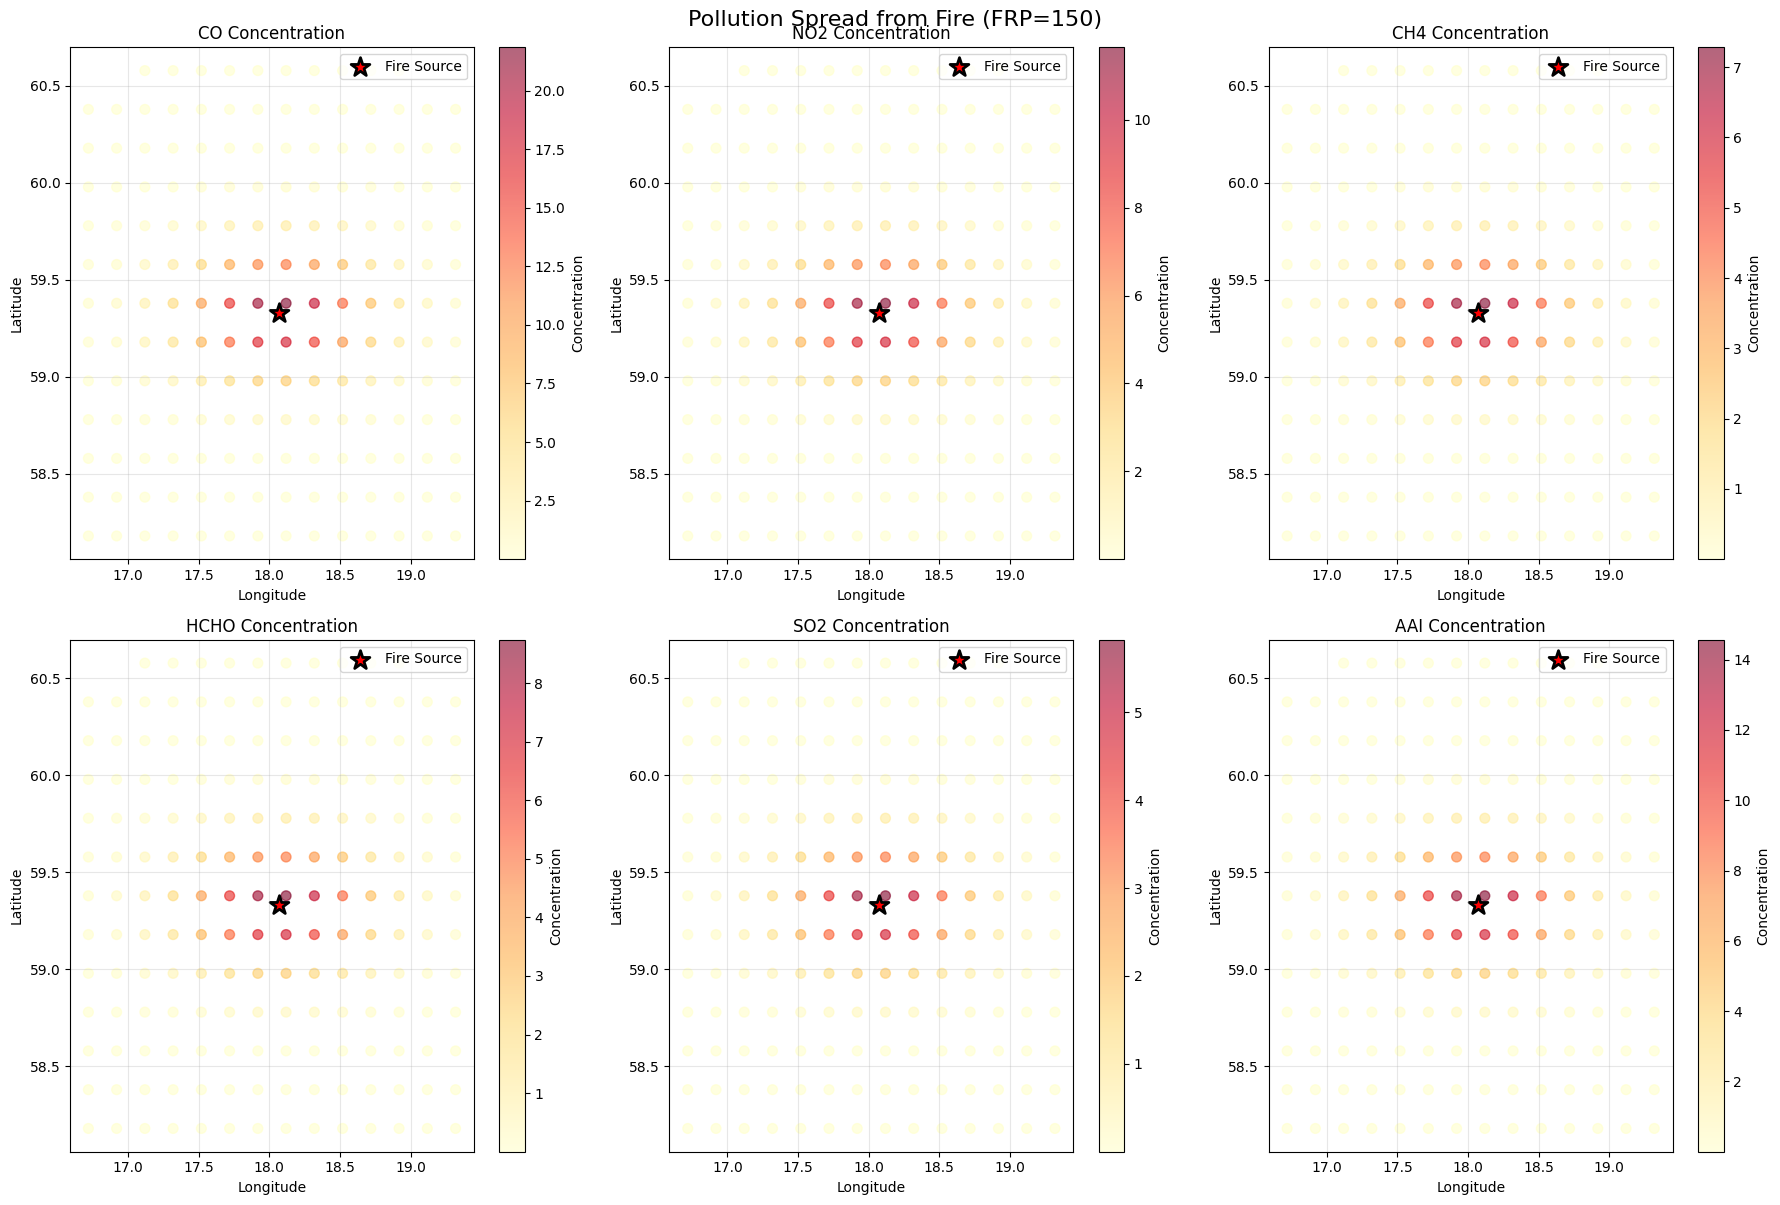

In [21]:
# Create plots for all pollutants
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, pollutant in enumerate(pollution_model.keys()):
    ax = axes[idx]
    
    # Create scatter plot colored by pollution level
    scatter = ax.scatter(
        df_simulation['longitude'],
        df_simulation['latitude'],
        c=df_simulation[pollutant],
        cmap='YlOrRd',
        s=50,
        alpha=0.6
    )
    
    # Mark fire location
    ax.scatter([stockholm_lon], [stockholm_lat], 
               color='red', s=200, marker='*', 
               edgecolors='black', linewidths=2,
               label='Fire Source')
    
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_title(f'{pollutant} Concentration')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Add colorbar
    plt.colorbar(scatter, ax=ax, label='Concentration')

plt.tight_layout()
plt.suptitle(f'Pollution Spread from Fire (FRP={example_frp})', 
             fontsize=16, y=1.00)
plt.show()

## 8. Export Functions for Web App

Save the model and functions so they can be used in your web application

In [22]:
# Create a module with all necessary functions
fire_impact_model = {
    'pollution_factors': pollution_model,
    'calculate_distance_km': calculate_distance_km,
    'pollution_concentration_at_distance': pollution_concentration_at_distance,
    'simulate_fire_pollution_impact': simulate_fire_pollution_impact
}

# Save to pickle for easy loading
import pickle

with open('../data/fire_impact_model.pkl', 'wb') as f:
    pickle.dump(fire_impact_model, f)

print("✅ Model saved to: ../data/fire_impact_model.pkl")
print("\nYou can load it in your web app with:")
print("  import pickle")
print("  with open('data/fire_impact_model.pkl', 'rb') as f:")
print("      model = pickle.load(f)")

✅ Model saved to: ../data/fire_impact_model.pkl

You can load it in your web app with:
  import pickle
  with open('data/fire_impact_model.pkl', 'rb') as f:
      model = pickle.load(f)


## 9. API Function for Web App

Simple API-style function that your webapp can call

In [23]:
def webapp_fire_simulation_api(lat, lon, frp, pollutants=['CO', 'NO2', 'AAI']):
    """
    Simplified API function for web app.
    
    Args:
        lat: Fire latitude
        lon: Fire longitude
        frp: Fire Radiative Power (suggested range: 10-500)
        pollutants: List of pollutants to calculate
    
    Returns:
        dict with:
        - 'grid_data': List of dicts with lat/lon/pollution values
        - 'summary': Overall statistics
    """
    
    # Validate inputs
    if not (-90 <= lat <= 90):
        return {'error': 'Invalid latitude'}
    if not (-180 <= lon <= 180):
        return {'error': 'Invalid longitude'}
    if frp <= 0:
        return {'error': 'FRP must be positive'}
    
    # Run simulation
    df_result = simulate_fire_pollution_impact(
        fire_lat=lat,
        fire_lon=lon,
        frp=frp,
        grid_resolution=0.15,
        radius_km=150
    )
    
    # Prepare output
    grid_data = df_result[['latitude', 'longitude', 'distance_km'] + pollutants].to_dict('records')
    
    summary = {
        'fire_location': {'lat': lat, 'lon': lon},
        'fire_intensity': frp,
        'grid_points': len(df_result),
        'max_distance_km': df_result['distance_km'].max(),
        'pollutant_peaks': {}
    }
    
    for pollutant in pollutants:
        summary['pollutant_peaks'][pollutant] = {
            'max': float(df_result[pollutant].max()),
            'mean': float(df_result[pollutant].mean())
        }
    
    return {
        'grid_data': grid_data,
        'summary': summary
    }

# Test the API
api_result = webapp_fire_simulation_api(
    lat=59.33,
    lon=18.07,
    frp=200,
    pollutants=['CO', 'NO2', 'AAI']
)

print("API Response Summary:")
print(api_result['summary'])
print(f"\nFirst 3 grid points:")
for point in api_result['grid_data'][:3]:
    print(point)

API Response Summary:
{'fire_location': {'lat': 59.33, 'lon': 18.07}, 'fire_intensity': 200, 'grid_points': 318, 'max_distance_km': np.float64(149.96290636272263), 'pollutant_peaks': {'CO': {'max': 29.999317104976843, 'mean': 2.6077057467595233}, 'NO2': {'max': 15.999635789320983, 'mean': 1.3907763982717456}, 'AAI': {'max': 19.99954473665123, 'mean': 1.7384704978396823}}}

First 3 grid points:
{'latitude': 58.12864864864864, 'longitude': 17.018648648648647, 'distance_km': 146.71699579964752, 'CO': 9.960144180459137e-07, 'NO2': 5.312076896244874e-07, 'AAI': 6.640096120306092e-07}
{'latitude': 58.12864864864864, 'longitude': 17.168648648648645, 'distance_km': 143.35417725116798, 'CO': 2.1735718568636774e-06, 'NO2': 1.159238323660628e-06, 'AAI': 1.449047904575785e-06}
{'latitude': 58.12864864864864, 'longitude': 17.318648648648644, 'distance_km': 140.44507000224465, 'CO': 4.207437486251077e-06, 'NO2': 2.243966659333908e-06, 'AAI': 2.804958324167385e-06}


## 10. Next Steps for Web App Integration

**To use this in your web application:**

1. **Load the model** in your backend:
   ```python
   import pickle
   with open('data/fire_impact_model.pkl', 'rb') as f:
       model = pickle.load(f)
   ```

2. **Create an API endpoint** (Flask/FastAPI example):
   ```python
   @app.post('/api/simulate-fire')
   def simulate_fire(lat: float, lon: float, frp: float):
       result = webapp_fire_simulation_api(lat, lon, frp)
       return jsonify(result)
   ```

3. **Frontend** (JavaScript):
   - Let users click on map to place fire
   - Send lat/lon/frp to backend API
   - Receive grid data and visualize as heatmap

4. **Improvements to make**:
   - Train on real fire-pollution correlations from your Sentinel-5P data
   - Add wind direction/speed to model directional spread
   - Include terrain effects (mountains block spread)
   - Add temporal evolution (how pollution changes over hours/days)
   - Calibrate pollution factors with real measurements

## 11. Save Example Simulation Data

Save example data for testing the web app

In [24]:
# Save example simulation as JSON for webapp testing
import json

example_data = {
    'fire_location': {
        'latitude': stockholm_lat,
        'longitude': stockholm_lon,
        'city': 'Stockholm'
    },
    'fire_intensity': example_frp,
    'simulation': api_result
}

with open('../data/example_fire_simulation.json', 'w') as f:
    json.dump(example_data, f, indent=2)

print("✅ Example simulation saved to: ../data/example_fire_simulation.json")
print("\nFile size:", len(json.dumps(example_data)), "bytes")

✅ Example simulation saved to: ../data/example_fire_simulation.json

File size: 59032 bytes
